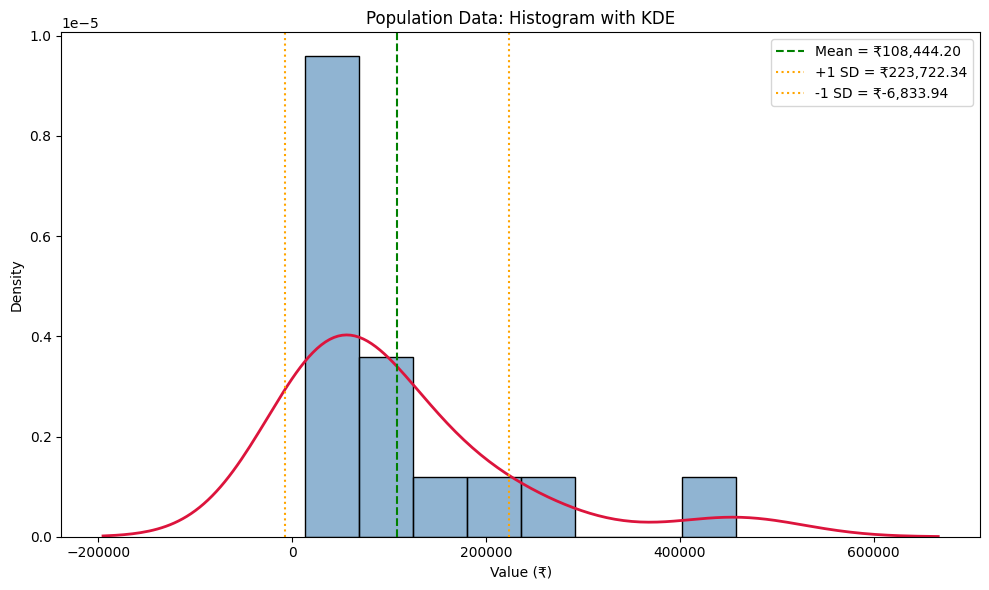

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = [48333, 120833, 35000, 50833, 13333, 32500, 23333, 183333,
        20000, 60000, 158333, 70833, 93333, 258333, 458333]

mean = np.mean(data)
std = np.std(data, ddof=0)   # population std

fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(data, bins=8, stat="density", color="steelblue",
             edgecolor="black", alpha=0.6, ax=ax)
sns.kdeplot(data, color="crimson", linewidth=2, ax=ax)

ax.axvline(mean, color="green", linestyle="--", label=f"Mean = ₹{mean:,.2f}")
ax.axvline(mean + std, color="orange", linestyle=":", label=f"+1 SD = ₹{mean+std:,.2f}")
ax.axvline(mean - std, color="orange", linestyle=":", label=f"-1 SD = ₹{mean-std:,.2f}")

ax.set_title("Population Data: Histogram with KDE")
ax.set_xlabel("Value (₹)")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

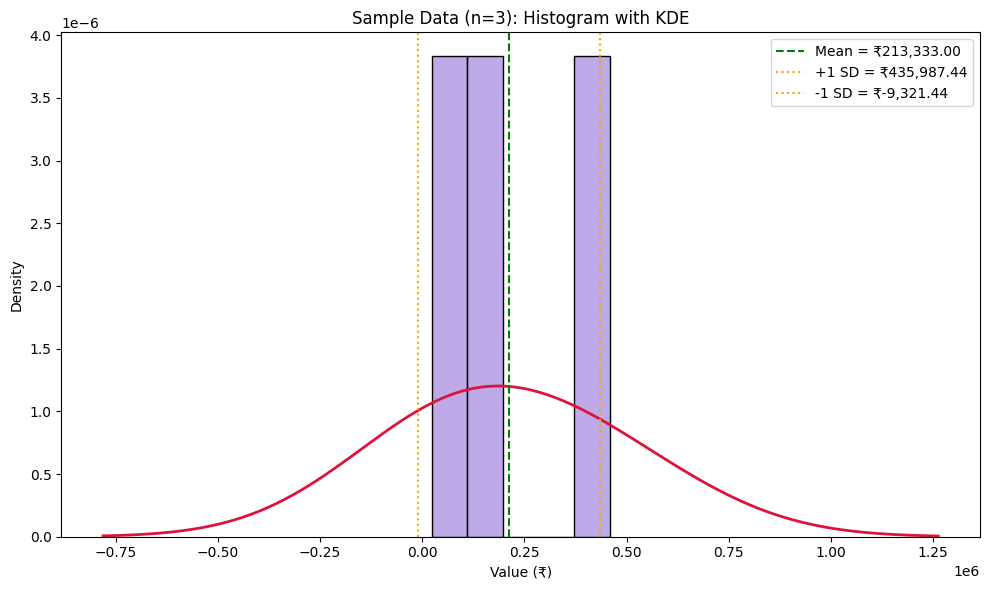

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sample = [158333, 23333, 458333]

mean = np.mean(sample)
std = np.std(sample, ddof=1)   # sample std (n-1)

fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(sample, bins=5, stat="density", color="mediumpurple",
             edgecolor="black", alpha=0.6, ax=ax)
sns.kdeplot(sample, color="crimson", linewidth=2, ax=ax, bw_adjust=1.5)

ax.axvline(mean, color="green", linestyle="--", label=f"Mean = ₹{mean:,.2f}")
ax.axvline(mean + std, color="orange", linestyle=":", label=f"+1 SD = ₹{mean+std:,.2f}")
ax.axvline(mean - std, color="orange", linestyle=":", label=f"-1 SD = ₹{mean-std:,.2f}")

ax.set_title("Sample Data (n=3): Histogram with KDE")
ax.set_xlabel("Value (₹)")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

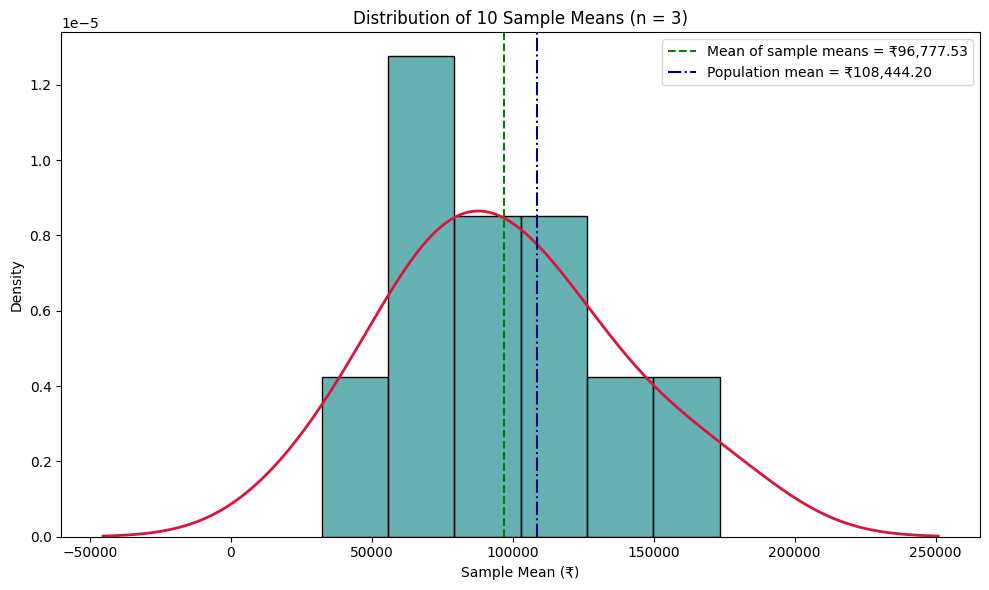

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sample_means = [68055.33, 32222.00, 87777.67, 140833.00, 173333.00,
                112222.00, 62777.67, 76388.67, 117499.67, 96666.33]

pop_mean = 108444.20                      # population mean from your data
mean_of_means = np.mean(sample_means)     # ≈ 96,777.53
std_of_means = np.std(sample_means, ddof=1)

fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(sample_means, bins=6, stat="density", color="teal",
             edgecolor="black", alpha=0.6, ax=ax)
sns.kdeplot(sample_means, color="crimson", linewidth=2, ax=ax)

ax.axvline(mean_of_means, color="green", linestyle="--",
           label=f"Mean of sample means = ₹{mean_of_means:,.2f}")
ax.axvline(pop_mean, color="navy", linestyle="-.",
           label=f"Population mean = ₹{pop_mean:,.2f}")

ax.set_title("Distribution of 10 Sample Means (n = 3)")
ax.set_xlabel("Sample Mean (₹)")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

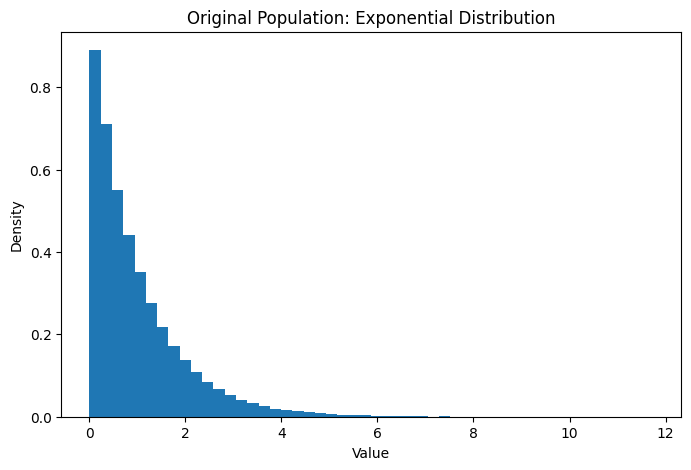

Population mean: 0.9959701590561849
Population standard deviation: 0.9929690473143962


In [7]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

population = np.random.exponential(scale=1, size=100000)

plt.figure(figsize=(8, 5))

plt.hist(population, bins=50, density=True)

plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Original Population: Exponential Distribution")

plt.show()

print("Population mean:", np.mean(population))
print("Population standard deviation:", np.std(population))

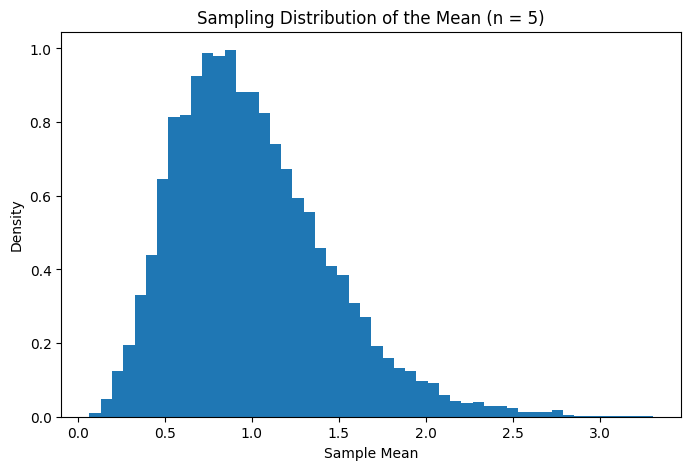

In [8]:
def get_sample_means(n, repetitions=10000):
    sample_means = []

    for _ in range(repetitions):
        sample = np.random.choice(population, size=n)
        sample_mean = np.mean(sample)
        sample_means.append(sample_mean)

    return np.array(sample_means)

n = 5

sample = np.random.choice(population, size=5)
sample_mean = np.mean(sample)
means_5 = get_sample_means(5)

plt.figure(figsize=(8, 5))

plt.hist(means_5, bins=50, density=True)

plt.xlabel("Sample Mean")
plt.ylabel("Density")
plt.title("Sampling Distribution of the Mean (n = 5)")

plt.show()

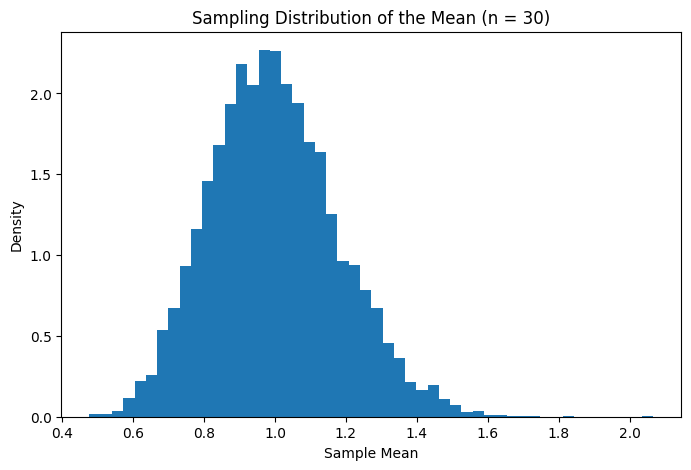

In [9]:
means_30 = get_sample_means(30)

plt.figure(figsize=(8, 5))

plt.hist(means_30, bins=50, density=True)

plt.xlabel("Sample Mean")
plt.ylabel("Density")
plt.title("Sampling Distribution of the Mean (n = 30)")

plt.show()

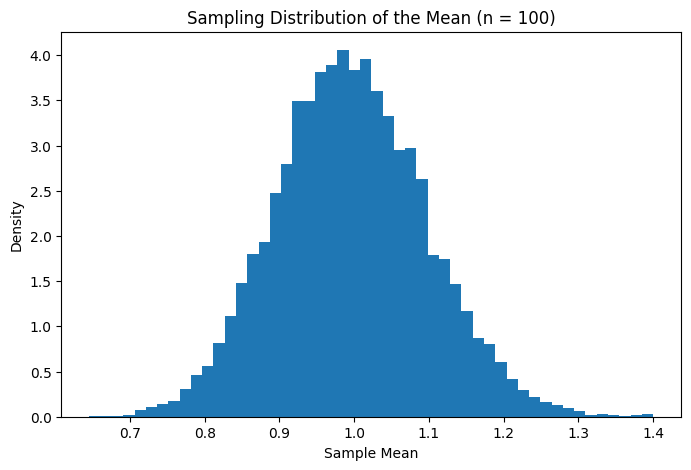

In [10]:
means_100 = get_sample_means(100)

plt.figure(figsize=(8, 5))

plt.hist(means_100, bins=50, density=True)

plt.xlabel("Sample Mean")
plt.ylabel("Density")
plt.title("Sampling Distribution of the Mean (n = 100)")

plt.show()

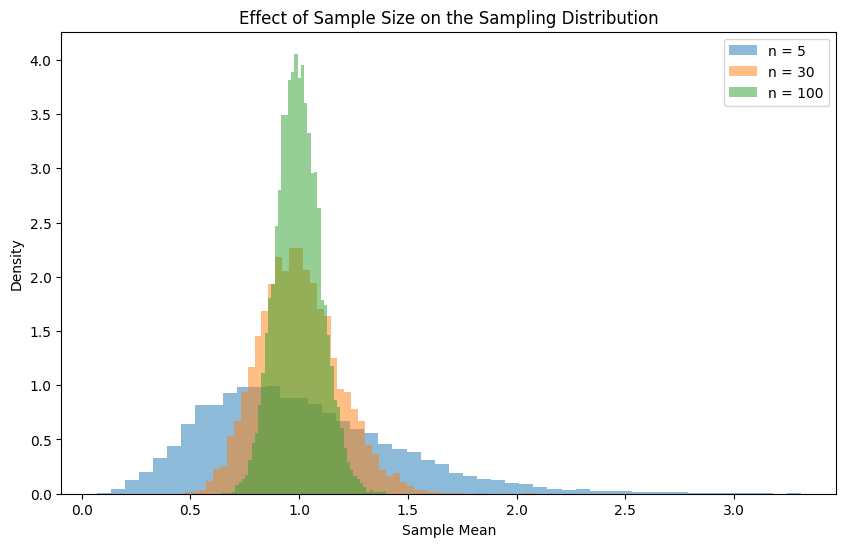

In [11]:
plt.figure(figsize=(10, 6))

plt.hist(means_5, bins=50, density=True, alpha=0.5, label="n = 5")
plt.hist(means_30, bins=50, density=True, alpha=0.5, label="n = 30")
plt.hist(means_100, bins=50, density=True, alpha=0.5, label="n = 100")

plt.xlabel("Sample Mean")
plt.ylabel("Density")
plt.title("Effect of Sample Size on the Sampling Distribution")

plt.legend()

plt.show()

In [12]:
print("n = 5")
print("Observed SE:", np.std(means_5))
print("Theoretical SE:", 1 / np.sqrt(5))

print("\nn = 30")
print("Observed SE:", np.std(means_30))
print("Theoretical SE:", 1 / np.sqrt(30))

print("\nn = 100")
print("Observed SE:", np.std(means_100))
print("Theoretical SE:", 1 / np.sqrt(100))

n = 5
Observed SE: 0.4447419217447357
Theoretical SE: 0.4472135954999579

n = 30
Observed SE: 0.1806763817640542
Theoretical SE: 0.18257418583505536

n = 100
Observed SE: 0.10073069414569462
Theoretical SE: 0.1


n =   5  ->  SE = 8.94
n =  30  ->  SE = 3.65
n = 100  ->  SE = 2.00


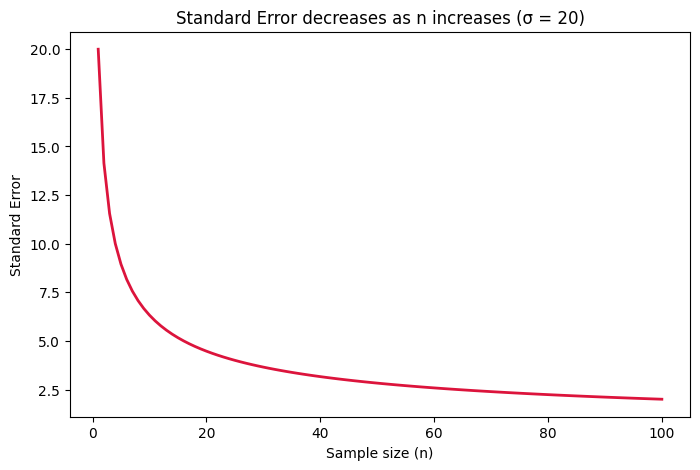

In [13]:
sigma_ex = 20

for n in [5, 30, 100]:
    print(f"n = {n:>3}  ->  SE = {sigma_ex / np.sqrt(n):.2f}")

n_values = np.arange(1, 101)
plt.figure(figsize=(8, 5))
plt.plot(n_values, sigma_ex / np.sqrt(n_values), color="crimson", linewidth=2)
plt.xlabel("Sample size (n)")
plt.ylabel("Standard Error")
plt.title("Standard Error decreases as n increases (σ = 20)")
plt.show()